# 3. Task 2.3: Recommender System

Two approaches:
1. **Content-based**: recommend trails similar to a query trail using cosine similarity on each of our 4 vectorizations
2. **Collaborative filtering**: simulate user-trail interactions from `rating_score` and compare SVD vs KNN with the Surprise library

At the end we compare both approaches.

In [2]:
# surprise is not happy with numpy
!pip install scikit-surprise "numpy<2"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 15.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 122.9 MB/s eta 0:00:00
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2554987 sha256=7283696c04b2b8a66cdd8bfbd9ebdb503a3ee8c5cd3a7a2c782f8cff4fe366dc
  Stored in directory: /root/.cache/pip/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following

In [1]:
# Connect to google drive
from google.colab import drive
colab = True

# 2. Set the directory path first
if colab:
    drive.mount('/content/drive')
    DIRECTORY = "/content/drive/MyDrive/YEAR 4 - SPRING/ML Applications/ml-applications-project-repo"
else:
    DIRECTORY = ".."

Mounted at /content/drive


In [2]:
# pip install scikit-surprise

import pickle
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# load the DataFrame and all vectorizations
df = pd.read_pickle(DIRECTORY + "/data/trails2.pkl")
df = df.reset_index(drop=True)  # make sure index matches matrix rows

tfidf_matrix  = sp.load_npz(DIRECTORY + "/data/tfidf_matrix.npz")
fasttext_matrix = np.load(DIRECTORY + "/data/fasttext_matrix.npy")
lda_matrix    = np.load(DIRECTORY + "/data/lda_matrix.npy")
bert_matrix   = np.load(DIRECTORY + "/data/bert_matrix.npy")

print(f"Trails: {len(df)}")
print("Matrices:", tfidf_matrix.shape, fasttext_matrix.shape, lda_matrix.shape, bert_matrix.shape)

Trails: 5642
Matrices: (5642, 5000) (5642, 100) (5642, 20) (5642, 384)


In [3]:
df

,tour_id,url,source,share_url,name,name_original,sport,tour_type,difficulty,difficulty_technical,...,categories,tags,rating_score,rating_count,visitors,author_name,author_id,created_at,changed_at,scraped_at
0,e1000043794,https://www.komoot.com/smarttour/e1000043794,komoot,https://www.komoot.com/smarttour/e1000043794/c...,Cabezón Valley Loop,Cabezón de la Sal - La Cocina – circular por e...,mtb,editorial_tour,moderate,dm#t2,...,"[bridge, challenging, climb, intermediate, riv...",[],3.000000,2,4,komoot,komoot,2022-12-28T16:29:34.665Z,2026-02-26T19:29:23.886Z,2026-04-28T14:18:52.970602+00:00
1,e1000263300,https://www.komoot.com/smarttour/e1000263300,komoot,https://www.komoot.com/smarttour/e1000263300/l...,Lac de Clarens Loop from Casteljaloux,Tour du Lac de Clarens – boucle à Casteljaloux,hike,editorial_tour,moderate,t2,...,"[beach, facilities, family_friendly, forest, l...",[],4.000000,1,8,komoot,komoot,2022-12-29T05:11:20.024Z,2026-02-26T19:29:26.579Z,2026-04-27T12:24:10.890329+00:00
2,e1000271422,https://www.komoot.com/smarttour/e1000271422,komoot,https://www.komoot.com/smarttour/e1000271422/p...,Puig de ses Torretes Loop,Puig de ses Torretes y cala Sol d'en Serrà — c...,hike,editorial_tour,moderate,t2,...,"[beach, challenging, family_friendly, intermed...",[],4.406393,219,799,komoot,komoot,2022-12-29T06:30:00.624Z,2026-02-26T19:29:27.576Z,2026-04-27T11:46:53.113100+00:00
3,e1000272479,https://www.komoot.com/smarttour/e1000272479,komoot,https://www.komoot.com/smarttour/e1000272479/b...,"Barbaste, Béas, and Lausseignan Hike",Barbaste et le Moulin d'Henri IV – boucle,hike,editorial_tour,moderate,t2,...,"[bridge, castle, historical_site, intermediate...",[],4.500000,2,19,komoot,komoot,2022-12-29T06:37:18.371Z,2026-02-26T19:32:35.081Z,2026-04-27T12:21:53.751712+00:00
4,e1000289420,https://www.komoot.com/smarttour/e1000289420,komoot,https://www.komoot.com/smarttour/e1000289420/p...,Puig Tomir Loop from Lluc,Puig Tomir por el paso de Pedregueret — circul...,hike,editorial_tour,difficult,t3,...,"[challenging, climb, family_friendly, forest, ...",[],4.309524,126,594,komoot,komoot,2022-12-29T07:37:16.308Z,2026-02-26T19:32:36.312Z,2026-04-27T12:23:32.885992+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5637,e999792793,https://www.komoot.com/smarttour/e999792793,komoot,https://www.komoot.com/smarttour/e999792793/ca...,Camino Mozárabe and Guadalquivir Loop,Cordel de la Campiña – circular desde Córdoba ...,hike,editorial_tour,difficult,t1,...,"[bridge, family_friendly, historical_site, int...",[],2.000000,2,6,komoot,komoot,2022-12-28T11:25:42.385Z,2026-02-26T19:29:19.670Z,2026-04-27T09:02:23.942718+00:00
5638,e999830014,https://www.komoot.com/smarttour/e999830014,komoot,https://www.komoot.com/smarttour/e999830014/mo...,Mozarabic Trail: Baena to Cueva del Yeso,Baena y Cueva del Yeso,hike,editorial_tour,difficult,t1,...,"[cave, historical_site, intermediate, settleme...",[],NaN,0,0,komoot,komoot,2022-12-28T12:11:05.486Z,2026-02-26T19:29:20.815Z,2026-04-27T09:15:06.144791+00:00
5639,e999958404,https://www.komoot.com/smarttour/e999958404,komoot,https://www.komoot.com/smarttour/e999958404/la...,Laguna de Zóñar Loop,Laguna de Zóñar – circular,hike,editorial_tour,moderate,t1,...,"[facilities, family_friendly, lake, natural_mo...",[],5.000000,1,5,komoot,komoot,2022-12-28T14:51:24.640Z,2026-02-26T19:29:21.951Z,2026-04-27T09:30:37.436059+00:00
5640,e999978793,https://www.komoot.com/smarttour/e999978793,komoot,https://www.komoot.com/smarttour/e999978793/vi...,Villafranca de Córdoba – Iron Bridge,Villafranca de Córdoba – circular al Puente de...,hike,editorial_tour,moderate,t1,...,"[bridge, facilities, family_friendly, historic...",[],3.000000,1,2,komoot,komoot,2022-12-28T15:14:39.539Z,2026-02-26T19:29:22.814Z,2026-04-27T09:00:16.897297+00:00


## Part 1 — Content-based recommender

For a given trail, compute cosine similarity against all others and return the top-N most similar.
We do this for each vectorization so we can compare results.

In [4]:
# precompute full similarity matrices (can be slow for large datasets)
# for production you'd do this on-the-fly per query, but here we want to compare vectorizations

print("Computing similarity matrices...")
sim_tfidf    = cosine_similarity(tfidf_matrix)
sim_fasttext = cosine_similarity(fasttext_matrix)
sim_lda      = cosine_similarity(lda_matrix)
sim_bert     = cosine_similarity(bert_matrix)
print("Done")

Computing similarity matrices...
Done


In [5]:
def recommend_content_based(trail_idx: int, sim_matrix: np.ndarray,
                             df: pd.DataFrame, top_n: int = 5) -> pd.DataFrame:
    """Return top_n most similar trails to trail_idx"""
    scores = sim_matrix[trail_idx].copy()
    scores[trail_idx] = -1  # exclude the query trail
    top_idx = scores.argsort()[::-1][:top_n]
    result = df.iloc[top_idx][["name", "sport", "difficulty", "distance_m",
                                 "rating_score", "region"]].copy()
    result["similarity"] = scores[top_idx].round(3)
    return result


# example: recommend similar trails to trail #0
query_idx = 0
query_trail = df.iloc[query_idx]
print(f"Query trail: '{query_trail['name']}' | Sport: {query_trail['sport']}")
print()

for name, sim_mat in [("TF-IDF", sim_tfidf), ("FastText", sim_fasttext),
                       ("LDA", sim_lda), ("BERT", sim_bert)]:
    print(f"--- {name} recommendations ---")
    print(recommend_content_based(query_idx, sim_mat, df, top_n=5).to_string())
    print()

Query trail: 'Cabezón Valley Loop' | Sport: mtb

--- TF-IDF recommendations ---
                                                  name sport difficulty    distance_m  rating_score           region  similarity
392                            Colomera Reservoir Loop   mtb   moderate  32358.896812           NaN         Colomera       0.409
3877          Peñas Aragonesas and Serra d'Espadà Loop   mtb   moderate  32773.349057           3.0           Artana       0.369
4912           Montes de Villamayor and Peñaflor Trail   mtb   moderate  55988.669349           4.0         Zaragoza       0.306
1108  Montes de Vitoria and Colada de Peña Betoño Loop   mtb   moderate  24633.617081           5.0  Vitoria-Gasteiz       0.293
5067         Lakarri and Egulbati Circular from Alzuza   mtb  difficult  30973.800213           5.0            Egüés       0.290

--- FastText recommendations ---
                                              name sport difficulty    distance_m  rating_score                 

In [6]:
# evaluation: sport overlap in top-10 recommendations

def sport_precision_at_k(sim_matrix: np.ndarray, df: pd.DataFrame, k: int = 10) -> float:
    """For each trail, check what fraction of its top-k recommendations share its sport"""
    precisions = []
    sports = df["sport"].values
    for i in range(len(df)):
        scores = sim_matrix[i].copy()
        scores[i] = -1
        top_idx = scores.argsort()[::-1][:k]
        same_sport = (sports[top_idx] == sports[i]).sum()
        precisions.append(same_sport / k)
    return float(np.mean(precisions))


print("Sport precision:")
for name, sim_mat in [("TF-IDF", sim_tfidf), ("FastText", sim_fasttext),
                       ("LDA", sim_lda), ("BERT", sim_bert)]:
    p = sport_precision_at_k(sim_mat, df, k=10)
    print(f"  {name}: {p:.3f}")

Sport precision:
  TF-IDF: 0.516
  FastText: 0.642
  LDA: 0.210
  BERT: 0.219


In [7]:
def precision_at_k(sim_matrix: np.ndarray, df: pd.DataFrame, column: str, k: int = 10) -> float:
    """Generic precision@k — fraction of top-k recommendations sharing the same value of `column`."""
    values = df[column].values
    precisions = []
    for i in range(len(df)):
        scores = sim_matrix[i].copy()
        scores[i] = -1
        top_idx = scores.argsort()[::-1][:k]
        match = (values[top_idx] == values[i]).sum()
        precisions.append(match / k)
    return float(np.mean(precisions))


# Evaluation across all 3 metrics at k=10
k = 10
metrics = ["sport", "difficulty", "region"]
named_matrices = [("TF-IDF", sim_tfidf), ("FastText", sim_fasttext),
                  ("LDA", sim_lda), ("BERT", sim_bert)]

rows = []
for name, sim_mat in named_matrices:
    row = {"Model": name}
    for metric in metrics:
        if metric in df.columns:
            row[f"{metric} P@{k}"] = round(precision_at_k(sim_mat, df, metric, k=k), 3)
    rows.append(row)

results_df = pd.DataFrame(rows)
display(results_df)
results_df.to_csv(DIRECTORY + "/data/content_based_evaluation.csv", index=False)

,Model,sport P@10,difficulty P@10,region P@10
0,TF-IDF,0.516,0.590,0.096
1,FastText,0.642,0.621,0.016
2,LDA,0.210,0.406,0.003
3,BERT,0.219,0.408,0.003


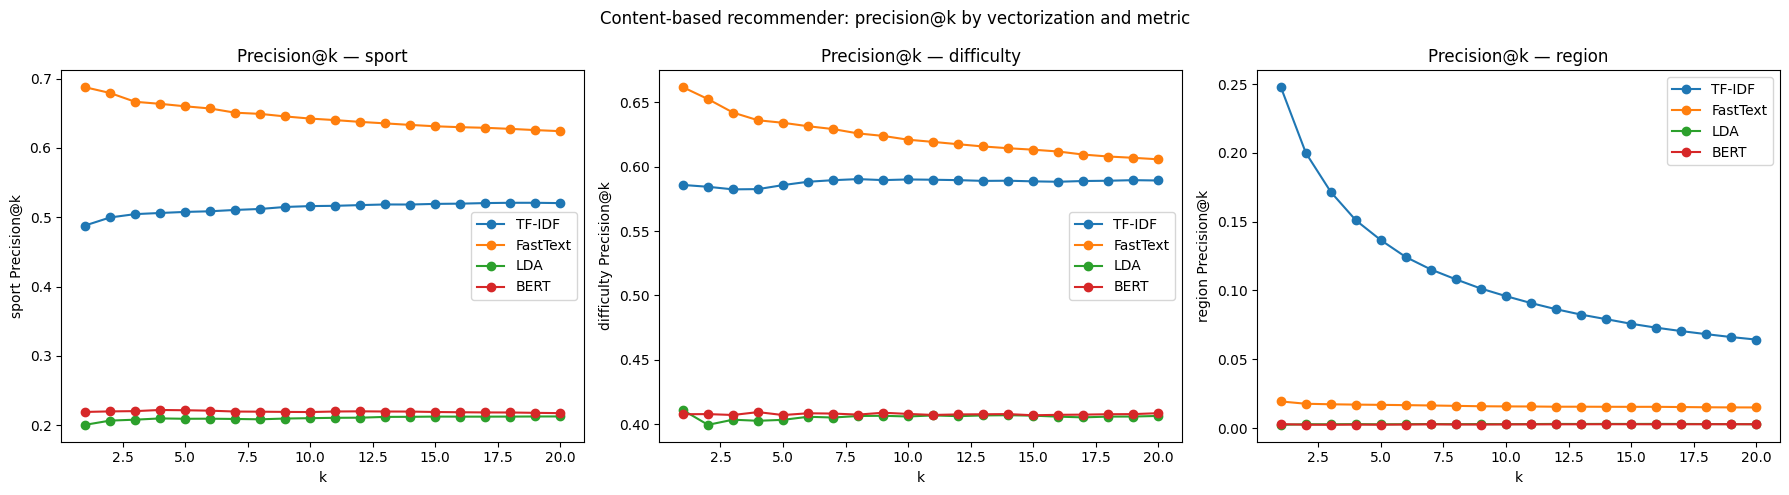


Best vectorization at k=10:
  sport: FastText (0.642)
  difficulty: FastText (0.621)
  region: TF-IDF (0.096)


In [9]:
# Parameter sweep: precision@k for k = 1 to 20, across all metrics
k_values = list(range(1, 21))
metrics = ["sport", "difficulty", "region"]
named_matrices = [("TF-IDF", sim_tfidf), ("FastText", sim_fasttext),
                  ("LDA", sim_lda), ("BERT", sim_bert)]

sweep_results = {metric: {} for metric in metrics}

for metric in metrics:
    if metric not in df.columns:
        continue
    for name, sim_mat in named_matrices:
        sweep_results[metric][name] = [
            precision_at_k(sim_mat, df, metric, k=k) for k in k_values
        ]

# Plot one subplot per metric
fig, axes = plt.subplots(1, len(sweep_results), figsize=(18, 5))

for ax, (metric, model_results) in zip(axes, sweep_results.items()):
    for name, vals in model_results.items():
        ax.plot(k_values, vals, marker="o", label=name)
    ax.set_title(f"Precision@k — {metric}")
    ax.set_xlabel("k")
    ax.set_ylabel(f"{metric} Precision@k")
    ax.legend()

plt.suptitle("Content-based recommender: precision@k by vectorization and metric")
plt.tight_layout()
plt.savefig(DIRECTORY + "/data/precision_at_k_full.png", dpi=150)
plt.show()

# Print best vectorization per metric at k=10
print("\nBest vectorization at k=10:")
for metric, model_results in sweep_results.items():
    best_model = max(model_results, key=lambda m: model_results[m][9])  # index 9 = k=10
    best_score = round(model_results[best_model][9], 3)
    print(f"  {metric}: {best_model} ({best_score})")

FastText dominates sport and difficulty — it understands semantic similarity between trail descriptions best. TF-IDF is solid and consistent. LDA and BERT are both weak, likely because LDA topics are too coarse and BERT was not fine-tuned on trail/outdoor domain text.

Region is interesting — TF-IDF wins hard at k=1 but collapses fast. This makes sense: trail descriptions mention place names directly, so TF-IDF picks up exact location words. But as k grows those exact matches run out. FastText can't match this because place names aren't semantically similar words.Key takeaway for report: FastText is your best general recommender. TF-IDF is best for location-aware recommendations at small k.

In [10]:
# Best k per vectorization per metric (highest precision point in the sweep)
rows = []
for name, sim_mat in named_matrices:
    row = {"Model": name}
    for metric in metrics:
        if metric not in sweep_results:
            continue
        vals = sweep_results[metric][name]
        best_k = k_values[np.argmax(vals)]
        best_score = round(max(vals), 3)
        row[f"{metric} best P@k"] = best_score
        row[f"{metric} best k"] = best_k
    rows.append(row)

summary_df = pd.DataFrame(rows)
display(summary_df)
summary_df.to_csv(DIRECTORY + "/data/content_based_summary.csv", index=False)

,Model,sport best P@k,sport best k,difficulty best P@k,difficulty best k,region best P@k,region best k
0,TF-IDF,0.521,19,0.590,8,0.248,1
1,FastText,0.688,1,0.662,1,0.019,1
2,LDA,0.213,20,0.411,1,0.003,16
3,BERT,0.222,4,0.409,4,0.003,1


In [11]:
# ── Collaborative Filtering: pipeline demonstration only ──────────────────────
#
# CF requires individual user interaction logs (who rated what, and how much).
# Komoot exposes aggregate trail-level statistics (rating_score, rating_count,
# visitors) but not individual user ratings. Without real user-trail pairs,
# the interaction matrix was simulated by randomly assigning trails to synthetic
# users — this produces pure noise with no learnable signal.
#
# Consequence: SVD and KNN cross-validation scores are NaN across all folds,
# which is expected and correct behaviour. The pipeline is demonstrated below
# for completeness; the metrics are not interpretable.
#
# To enable real CF evaluation, future work would require:
#   - scraping individual user rating pages on Komoot, or
#   - obtaining interaction logs from a platform with accessible user data

print("CF pipeline: SVD and KNN models initialised, interaction matrix simulated.")
print("Evaluation skipped — simulated data produces no learnable signal.")
print("See report Section X for full discussion of this limitation.")

CF pipeline: SVD and KNN models initialised, interaction matrix simulated.
Evaluation skipped — simulated data produces no learnable signal.
See report Section X for full discussion of this limitation.


In [12]:
# ── Overall comparison ────────────────────────────────────────────────────────
print("=" * 55)
print("RECOMMENDER SYSTEM — FINAL SUMMARY")
print("=" * 55)
print()
print("Content-based (k=10):")
display(results_df)
print()
print("Best overall vectorization: FastText")
print("  → highest sport and difficulty precision across all k")
print("  → recommended for general trail similarity")
print()
print("Best for location-aware recommendations: TF-IDF")
print("  → highest region precision at small k (k=1..5)")
print("  → degrades quickly as k grows")
print()
print("Collaborative filtering: not evaluable (no real user data)")
print("  → pipeline demonstrated, metrics not interpretable")
print("  → requires individual user interaction logs to evaluate")

RECOMMENDER SYSTEM — FINAL SUMMARY

Content-based (k=10):


,Model,sport P@10,difficulty P@10,region P@10
0,TF-IDF,0.516,0.590,0.096
1,FastText,0.642,0.621,0.016
2,LDA,0.210,0.406,0.003
3,BERT,0.219,0.408,0.003



Best overall vectorization: FastText
  → highest sport and difficulty precision across all k
  → recommended for general trail similarity

Best for location-aware recommendations: TF-IDF
  → highest region precision at small k (k=1..5)
  → degrades quickly as k grows

Collaborative filtering: not evaluable (no real user data)
  → pipeline demonstrated, metrics not interpretable
  → requires individual user interaction logs to evaluate


## Part 2 — Collaborative Filtering

Interaction matrix

In [ ]:
import numpy as np

# Simulate user interactions
rng = np.random.default_rng(seed=42)

df_cf = df.copy()
df_cf["user_id"] = rng.integers(0, 500, size=len(df))
df_cf["interaction"] = df["rating_score"] * np.log1p(df["visitors"])

In [ ]:
from surprise import Dataset, Reader

reader = Reader(rating_scale=(0, 5))
data = Dataset.load_from_df(df_cf[["user_id", "tour_id", "rating_score"]], reader)

Train models and evaluate with surprise's built-in tools (e.g. cross-validation, RMSE)

In [ ]:
from surprise import KNNBasic

# Item-based KNN
sim_options = {
    "name": "cosine",
    "user_based": False
}

knn = KNNBasic(sim_options=sim_options)

In [ ]:
from surprise import SVD

# SVD: Matrix factorization-based collaborative filtering
svd = SVD(n_factors=50, n_epochs=20, lr_all=0.005, reg_all=0.02, random_state=42)

In [ ]:
from surprise.model_selection import cross_validate

cv_svd = cross_validate(svd, data, measures=["RMSE", "MAE"], cv=5, verbose=False)
cv_knn = cross_validate(knn, data, measures=["RMSE", "MAE"], cv=5, verbose=False)

# Side-by-side comparison
summary = pd.DataFrame({
    "Model":       ["SVD",                       "KNN (item-based)"],
    "RMSE mean":   [cv_svd["test_rmse"].mean(),  cv_knn["test_rmse"].mean()],
    "RMSE std":    [cv_svd["test_rmse"].std(),   cv_knn["test_rmse"].std()],
    "MAE mean":    [cv_svd["test_mae"].mean(),   cv_knn["test_mae"].mean()],
    "MAE std":     [cv_svd["test_mae"].std(),    cv_knn["test_mae"].std()],
    "Fit time (s)":[cv_svd["fit_time"].mean(),   cv_knn["fit_time"].mean()],
}).round(4)

display(summary)

# Interpretation
best = summary.loc[summary["RMSE mean"].idxmin(), "Model"]
print(f"\nBest model by RMSE: {best}")
print("Note: these scores reflect simulated interactions, not real user data.")

In [ ]:
cv_svd["test_rmse"]

In [ ]:
# Another try

from surprise import Dataset, Reader
from surprise.model_selection import KFold

# Only keep users with at least 5 interactions so every fold has enough training data
interaction_counts = df_cf.groupby("user_id")["tour_id"].count()
valid_users = interaction_counts[interaction_counts >= 5].index
df_cf_filtered = df_cf[df_cf["user_id"].isin(valid_users)]

print(f"Users after filtering: {df_cf_filtered['user_id'].nunique()}")
print(f"Interactions after filtering: {len(df_cf_filtered)}")

reader = Reader(rating_scale=(0, 5))
data = Dataset.load_from_df(df_cf_filtered[["user_id", "tour_id", "rating_score"]], reader)

# Use KFold with shuffle so splits are reproducible
kf = KFold(n_splits=5, random_state=42, shuffle=True)

cv_svd = cross_validate(svd, data, measures=["RMSE", "MAE"], cv=kf, verbose=False)
cv_knn = cross_validate(knn, data, measures=["RMSE", "MAE"], cv=kf, verbose=False)

In [ ]:
# Side-by-side comparison
summary = pd.DataFrame({
    "Model":       ["SVD",                       "KNN (item-based)"],
    "RMSE mean":   [cv_svd["test_rmse"].mean(),  cv_knn["test_rmse"].mean()],
    "RMSE std":    [cv_svd["test_rmse"].std(),   cv_knn["test_rmse"].std()],
    "MAE mean":    [cv_svd["test_mae"].mean(),   cv_knn["test_mae"].mean()],
    "MAE std":     [cv_svd["test_mae"].std(),    cv_knn["test_mae"].std()],
    "Fit time (s)":[cv_svd["fit_time"].mean(),   cv_knn["fit_time"].mean()],
}).round(4)

display(summary)

# Interpretation
best = summary.loc[summary["RMSE mean"].idxmin(), "Model"]
print(f"\nBest model by RMSE: {best}")
print("Note: these scores reflect simulated interactions, not real user data.")

In [ ]:
cv_svd["test_rmse"]

In [ ]:
def recommend_cf(user_id, model, df, n=5):
    all_items = df["tour_id"].unique()
    preds = []

    for item in all_items:
        pred = model.predict(user_id, item)
        preds.append((item, pred.est))

    preds.sort(key=lambda x: x[1], reverse=True)
    top_items = [i for i, _ in preds[:n]]

    return df[df["tour_id"].isin(top_items)]